# IMDB Movie Review — Binary Sentiment Classification using DNN

**Problem Statement:** Classify movie reviews into **Positive** or **Negative** sentiment based solely on the text content of the review using a Deep Neural Network (DNN).

**Dataset:** IMDB Movie Reviews  
**Model:** Deep Neural Network (DNN) with Dense layers

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the IMDB Dataset

**Way 1:** Download from Kaggle — place `IMDB Dataset.csv` in same folder.  

**Way 2:** Use Keras built-in IMDB dataset (easiest).
> The IMDB dataset has **50,000** movie reviews — 25,000 for training and 25,000 for testing.  
> Labels: **0 = Negative**, **1 = Positive**  
> Reviews are already tokenised: each word → integer index.  
> `num_words=10000` keeps only the **10,000 most frequent words**.

In [3]:
# ── Way 1: Load from Kaggle CSV ────────

# df = pd.read_csv('IMDB Dataset.csv')

# from sklearn.model_selection import train_test_split

# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df['sentiment'] = le.fit_transform(df['sentiment'])   # positive=1, negative=0

# # (further text vectorization would be needed — see notes)

In [4]:
# ── Way 2: Use Keras built-in dataset (active) ──────────────────────────────────
from tensorflow.keras.datasets import imdb

NUM_WORDS = 10000         # Vocabulary size: keep top 10,000 words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f"  Training samples : {len(X_train):,}")
print(f"  Test samples     : {len(X_test):,}")
print(f"  Classes          : 0 = Negative | 1 = Positive")

  Training samples : 25,000
  Test samples     : 25,000
  Classes          : 0 = Negative | 1 = Positive


## Step 3: Explore the Data (EDA)

In [5]:
# Check class balance
unique, counts = np.unique(y_train, return_counts=True)
print("Training class balance:")
for label, count in zip(['Negative', 'Positive'], counts):
    print(f"  {label}: {count:,}")

Training class balance:
  Negative: 12,500
  Positive: 12,500


In [6]:
# Review length statistics
train_lengths = [len(r) for r in X_train]
print(f"\nReview length (# of words):")
print(f"  Min    : {np.min(train_lengths)}")
print(f"  Max    : {np.max(train_lengths)}")
print(f"  Mean   : {np.mean(train_lengths):.1f}")
print(f"  Median : {np.median(train_lengths):.1f}")


Review length (# of words):
  Min    : 11
  Max    : 2494
  Mean   : 238.7
  Median : 178.0


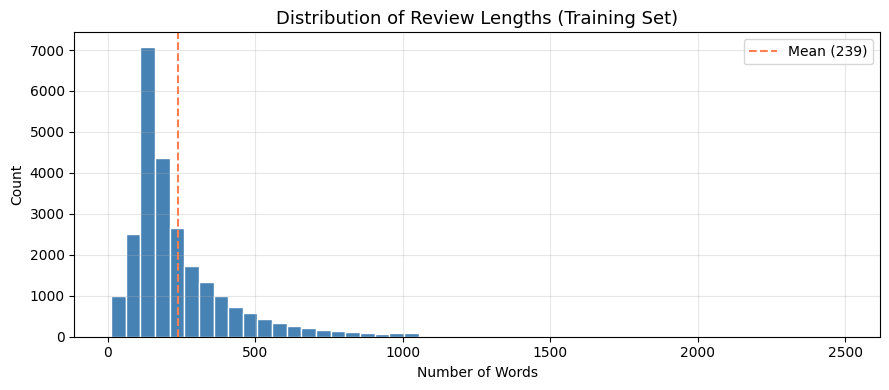

In [7]:
# Plot review length distribution
plt.figure(figsize=(9, 4))
plt.hist(train_lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.mean(train_lengths), color='coral', linestyle='--', linewidth=1.5, label=f'Mean ({np.mean(train_lengths):.0f})')
plt.title('Distribution of Review Lengths (Training Set)', fontsize=13)
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Decode and print a sample review (for understanding)
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

# Decode first review (indices are offset by 3 due to reserved tokens)
sample_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in X_train[0]])

print(f"Sample review (label = {'Positive' if y_train[0] == 1 else 'Negative'}):")
print()
print(sample_review[:500], '...')

Sample review (label = Positive):

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to ever ...


## Step 4: Preprocess the Data

### 4a. Multi-Hot (Binary) Vectorisation

Instead of using raw word indices (which loses meaning), we convert each review into a
**fixed-length binary vector of size NUM_WORDS**.  
- Each position represents one word in the vocabulary.
- **1** = the word appears in the review, **0** = it does not.
- This is the correct "Bag-of-Words" representation for DNN text classification.

> ⚠️ **Why not pad + normalise indices?**  
> Word index 42 and 43 represent completely different words, not similar ones.  
> Treating them as numbers (42/10000 vs 43/10000) misleads the network.  
> Multi-hot encoding treats each word independently — which is correct.

In [9]:
def vectorize_sequences(sequences, dimension=NUM_WORDS):
    """Convert a list of integer sequences to a 2D binary matrix."""
    results = np.zeros((len(sequences), dimension), dtype='float32')
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0   # mark present words as 1
    return results

X_train_vec = vectorize_sequences(X_train)
X_test_vec  = vectorize_sequences(X_test)

print("After vectorisation:")
print("  X_train shape:", X_train_vec.shape)
print("  X_test shape :", X_test_vec.shape)
print(f"  Values        : 0.0 or 1.0 only")

After vectorisation:
  X_train shape: (25000, 10000)
  X_test shape : (25000, 10000)
  Values        : 0.0 or 1.0 only


### 4b. Convert Labels to Float
The labels (0/1 integers) need to be float32 for Keras binary cross-entropy.

In [10]:
y_train_f = y_train.astype('float32')
y_test_f  = y_test.astype('float32')

print("Label dtype:", y_train_f.dtype)
print("Sample labels:", y_train_f[:5])

Label dtype: float32
Sample labels: [1. 0. 0. 1. 0.]


## Step 5: Build the DNN Model

We build a simple **fully-connected (Dense) neural network**:
- **Input layer** — 10,000 neurons (one per vocabulary word)
- **Hidden layers** — Dense layers with ReLU activation
- **Output layer** — 1 neuron with **Sigmoid** (outputs probability between 0 and 1)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [12]:
model = Sequential([
    # Hidden layer 1
    Dense(16, activation='relu', input_shape=(NUM_WORDS,)),

    # Hidden layer 2
    Dense(16, activation='relu'),

    # Output layer — sigmoid gives probability (0=Negative, 1=Positive)
    Dense(1, activation='sigmoid')
])

In [13]:
# Compile the model
model.compile( optimizer='rmsprop', loss='binary_crossentropy',  metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │         160,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

In [15]:
history = model.fit( X_train_vec, y_train_f, epochs=20, batch_size=512, validation_split=0.1,  verbose=1)

print("\nTraining complete!")

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8103 - loss: 0.4600 - val_accuracy: 0.8856 - val_loss: 0.3263
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9034 - loss: 0.2695 - val_accuracy: 0.8940 - val_loss: 0.2880
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9228 - loss: 0.2118 - val_accuracy: 0.8920 - val_loss: 0.2832
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9381 - loss: 0.1762 - val_accuracy: 0.8868 - val_loss: 0.2974
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9457 - loss: 0.1556 - val_accuracy: 0.8908 - val_loss: 0.2926
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9535 - loss: 0.1361 - val_accuracy: 0.8912 - val_loss: 0.3051
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9585 - loss: 0.1213 - val_accuracy: 0.8884 - val_loss: 0.3191
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9616 - loss: 0.1120 - val_accuracy: 0.8860 - v

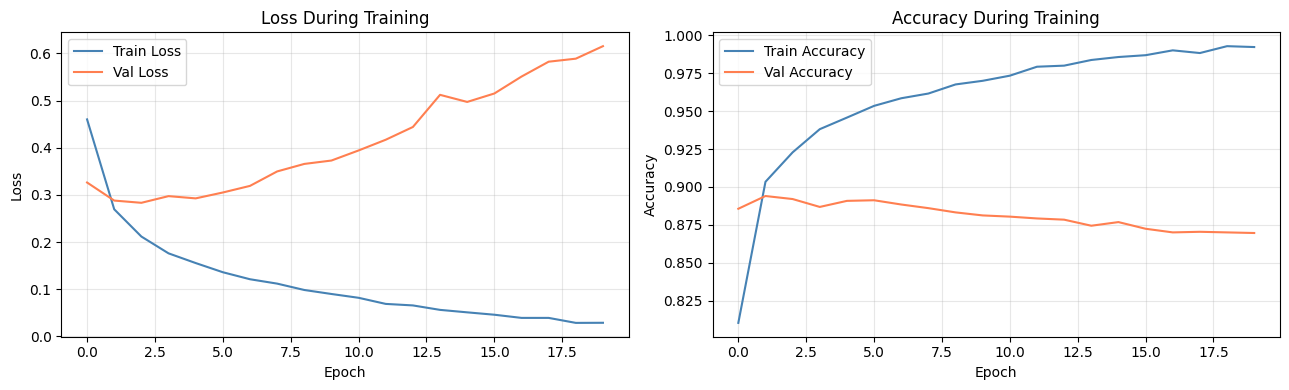

In [16]:
# Plot Training vs Validation — Loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss',  color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',    color='coral')
axes[0].set_title('Loss During Training', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Training vs Validation — Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral')
axes[1].set_title('Accuracy During Training', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Evaluate the Model on Test Data

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_vec, y_test_f, verbose=0)

In [19]:
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

Test Loss     : 0.6403
Test Accuracy : 85.85%


In [20]:
# Get predictions (probabilities → class labels)
y_pred_prob = model.predict(X_test_vec)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()   # 0 or 1

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [21]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86     12500
    Positive       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



## Step 8: Visualise Results

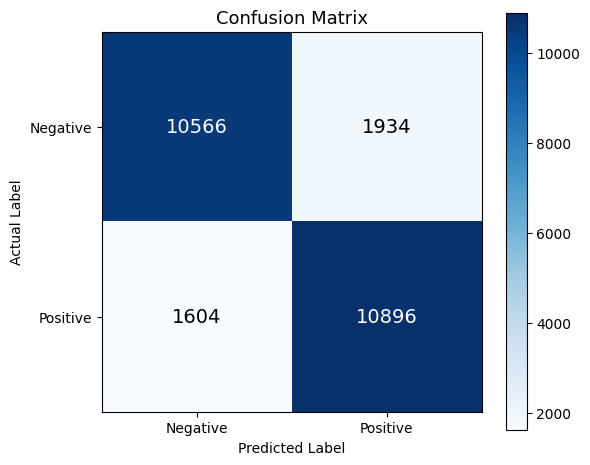

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

labels = ['Negative', 'Positive']

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix', fontsize=13)
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

# Add text inside the matrix cells
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black',
                 fontsize=14)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()